# 🏥 HCR4 — Finetuning TrOCR sur Ordonnances Médicales

Ce notebook fine-tune le modèle **TrOCR** (Microsoft) sur votre dataset de crops d'ordonnances manuscrites.

**Format du dataset** : Chaque image (crop) contient **une seule ligne** de médicament, associée à son texte dans `annotations.csv`.

---

**Avant de commencer :**
1. Allez dans **Exécution > Modifier le type d'exécution > GPU (T4)**
2. Uploadez le fichier `hcr4_dataset.zip` dans le panneau Fichiers (à gauche)

---

## Étape 1 — Installation des dépendances

In [1]:
!pip install -q transformers[torch] datasets evaluate jiwer Pillow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.9 MB/s eta 0:00:00


## Étape 2 — Upload et décompression du dataset

**Option A** : Upload direct (exécutez la cellule ci-dessous, une fenêtre s'ouvrira pour choisir `hcr4_dataset.zip`)

**Option B** : Si vous avez déjà uploadé le fichier manuellement dans le panneau Fichiers, passez directement à la décompression.

In [2]:
# Option A : Upload interactif
from google.colab import files
uploaded = files.upload()  # Sélectionnez hcr4_dataset.zip

Saving colab_finetuning_v4.zip to colab_finetuning_v4.zip


In [3]:
# Décompression du dataset
!unzip -o colab_finetuning_v4.zip -d .

# Vérification
import os
n_images = len(os.listdir('dataset/images'))
print(f"\n✅ Dataset décompressé : {n_images} crops trouvés")
print(f"📄 Fichier CSV : {'dataset/annotations.csv' if os.path.exists('dataset/annotations.csv') else '❌ INTROUVABLE'}")

Archive:  colab_finetuning_v4.zip
  inflating: ./HCR4_Finetuning_TrOCR.ipynb  
   creating: ./dataset/
  inflating: ./dataset/annotations.csv  
  inflating: ./dataset/_eval_split.csv  
   creating: ./dataset/images/
  inflating: ./dataset/images/augA_69_a.jpeg  
  inflating: ./dataset/images/augB_2_a.jpeg  
  inflating: ./dataset/images/augB_11_a.jpeg  
  inflating: ./dataset/images/augB_31_a.jpeg  
  inflating: ./dataset/images/augA_13_b.jpeg  
  inflating: ./dataset/images/28_b.jpeg  
  inflating: ./dataset/images/70_h.jpeg  
  inflating: ./dataset/images/augB_6_a.jpeg  
  inflating: ./dataset/images/augB_10_a.jpeg  
  inflating: ./dataset/images/augA_85_b.jpeg  
  inflating: ./dataset/images/12_c.jpeg  
  inflating: ./dataset/images/46_b.jpeg  
  inflating: ./dataset/images/48_a.jpeg  
  inflating: ./dataset/images/76_d.jpeg  
  inflating: ./dataset/images/augA_70_d.jpeg  
  inflating: ./dataset/images/81_a.jpeg  
  inflating: ./dataset/images/29_b.jpeg  
  inflating: ./dataset/imag

## Étape 3 — Vérification du GPU

In [4]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU détecté : {gpu_name} ({gpu_mem:.1f} GB VRAM)")
else:
    print("⚠️ Aucun GPU détecté ! Allez dans Exécution > Modifier le type d'exécution > GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📌 Device utilisé : {device}")

✅ GPU détecté : Tesla T4 (15.6 GB VRAM)
📌 Device utilisé : cuda


## Étape 4 — Chargement du modèle TrOCR et du processeur

In [5]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_NAME = "microsoft/trocr-base-handwritten"
MAX_TARGET_LENGTH = 128  # Chaque crop = 1 seul médicament (texte court)

print(f"📥 Chargement de {MODEL_NAME}...")
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Configuration du décodeur (ces paramètres restent sur model.config car ils concernent la configuration du modèle)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.eos_token_id = processor.tokenizer.sep_token_id

# Configuration des paramètres de génération (doivent être sur model.generation_config)
model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

model.to(device)
print(f"✅ Modèle chargé sur {device}")

📥 Chargement de microsoft/trocr-base-handwritten...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modèle chargé sur cuda


## Étape 5 — Préparation du Dataset PyTorch

In [6]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

class PrescriptionDataset(Dataset):
    """Dataset PyTorch pour crops d'ordonnances HCR4.

    Chaque image (crop) contient une seule ligne de médicament.
    """

    def __init__(self, csv_file, root_dir, processor, max_target_length=128):
        raw_df = pd.read_csv(csv_file)
        self.df = raw_df.drop_duplicates(subset='file_name', keep='last').reset_index(drop=True)
        self.root_dir = root_dir
        self.processor = processor
        self.max_target_length = max_target_length

        # Vérification des images manquantes
        missing = [f for f in self.df['file_name'] if not os.path.isfile(os.path.join(root_dir, str(f)))]
        if missing:
            print(f"⚠️ {len(missing)} image(s) manquante(s) : {missing[:5]}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_name = str(row['file_name'])
        text = str(row['text']).strip()

        image_path = os.path.join(self.root_dir, file_name)
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (384, 384))

        pixel_values = self.processor(image, return_tensors='pt').pixel_values

        labels = self.processor.tokenizer(
            text, padding='max_length',
            max_length=self.max_target_length, truncation=True
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {
            'pixel_values': pixel_values.squeeze(),
            'labels': torch.tensor(labels)
        }

print("✅ Classe PrescriptionDataset définie.")

✅ Classe PrescriptionDataset définie.


In [7]:
# Utilisation des splits pré-générés pour éviter le Data Leakage des augmentations
import os

TRAIN_CSV = 'dataset/_train_split.csv'
EVAL_CSV = 'dataset/_eval_split.csv'
IMAGES_DIR = 'dataset/images'

train_dataset = PrescriptionDataset(TRAIN_CSV, IMAGES_DIR, processor, MAX_TARGET_LENGTH)
eval_dataset = PrescriptionDataset(EVAL_CSV, IMAGES_DIR, processor, MAX_TARGET_LENGTH)

print(f'🏋️ Entraînement : {len(train_dataset)} crops')
print(f'🧪 Évaluation   : {len(eval_dataset)} crops')


🏋️ Entraînement : 855 crops
🧪 Évaluation   : 50 crops


## Étape 6 — Configuration et lancement de l'entraînement

In [8]:
import evaluate

cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

def compute_metrics(pred):
    """Calcule le WER (Word Error Rate) et le CER (Character Error Rate).

    WER = métrique principale : mesure si les noms de médicaments
          sont correctement reconnus mot par mot.
    CER = métrique secondaire : diagnostic au niveau caractère.
    """
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # Remplacer -100 par pad_token_id
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': wer, 'cer': cer}

print("✅ Métriques WER + CER prêtes.")

✅ Métriques WER + CER prêtes.


In [9]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator

# ============================
# HYPER-PARAMETRES (AJUSTÉS POUR ÉVITER OOM)
# ============================
NUM_EPOCHS = 12
BATCH_SIZE = 4             # Réduit de 16 à 4 pour économiser la VRAM
LEARNING_RATE = 3e-5
GRADIENT_ACCUMULATION = 8  # 4 * 8 = 32 (on garde le même batch effectif)

training_args = Seq2SeqTrainingArguments(
    output_dir="./checkpoints",
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    weight_decay=0.05,
    num_train_epochs=NUM_EPOCHS,
    fp16=torch.cuda.is_available(),
    logging_steps=10,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none",
    dataloader_num_workers=2,
    remove_unused_columns=False,
    warmup_ratio=0.1,
)

trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)

print(f"🚀 Prêt avec paramètres optimisés ! Batch effectif = {BATCH_SIZE * GRADIENT_ACCUMULATION}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Prêt avec paramètres optimisés ! Batch effectif = 32


In [10]:
# Nettoyage de la mémoire avant de lancer
import torch
torch.cuda.empty_cache()

# ============================
# LANCEMENT DE L'ENTRAÎNEMENT
# ============================
print("🏋️ Entraînement en cours (optimisé pour la mémoire)...")
trainer.train()
print("\n✅ Entraînement terminé !")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


🏋️ Entraînement en cours (optimisé pour la mémoire)...


Epoch,Training Loss,Validation Loss,Wer,Cer
1,33.257138,1.625640,0.670103,0.320064
2,5.025202,1.361936,0.567010,0.278662
3,1.446520,1.560473,0.546392,0.272293
4,0.774581,1.517669,0.536082,0.313694
5,0.530020,1.618939,0.505155,0.313694
6,0.272420,1.678523,0.494845,0.270701
7,0.222264,1.737721,0.536082,0.275478
8,0.159069,1.819560,0.463918,0.237261
9,0.021269,1.872509,0.463918,0.240446
10,0.004991,1.869403,0.463918,0.242038


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.layers.0.attention.q_proj.weight', 'encoder.layers.0.attention.k_proj.weight', 'encoder.layers.0.attention.v_proj.weight', 'encoder.layers.0.attention.o_proj.weight', 'encoder.layers.0.attention.o_proj.bias', 'encoder.layers.0.layernorm_before.weight', 'encoder.layers.0.layernorm_before.bias', 'encoder.layers.0.layernorm_after.weight', 'encoder.layers.0.layernorm_after.bias', 'encoder.layers.0.mlp.fc1.weight', 'encoder.layers.0.mlp.fc1.bias', 'encoder.layers.0.mlp.fc2.weight', 'encoder.layers.0.mlp.fc2.bias', 'encoder.layers.1.attention.q_proj.weight', 'encoder.layers.1.attention.k_proj.weight', 'encoder.layers.1.attention.v_proj.weight', 'encoder.layers.1.attention.o_proj.weight', 'encoder.layers.1.attention.o_proj.bias', 'encoder.layers.1.layernorm_before.weight', 'encoder.layers.1.layernorm_before.bias', 'encoder.layers.1.layernorm_after.weight', 'encoder.layers.1.layernorm_after.bias', 'encoder.layers.


✅ Entraînement terminé !


## Étape 7 — Sauvegarde du modèle fine-tuné

In [11]:
FINAL_DIR = './trocr_finetuned_hcr4'

trainer.save_model(FINAL_DIR)
processor.save_pretrained(FINAL_DIR)

print(f"💾 Modèle sauvegardé dans : {FINAL_DIR}")

# Lister les fichiers sauvegardés
for f in os.listdir(FINAL_DIR):
    size = os.path.getsize(os.path.join(FINAL_DIR, f)) / 1e6
    print(f"   {f} ({size:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Modèle sauvegardé dans : ./trocr_finetuned_hcr4
   model.safetensors (1335.7 MB)
   generation_config.json (0.0 MB)
   config.json (0.0 MB)
   processor_config.json (0.0 MB)
   tokenizer_config.json (0.0 MB)
   tokenizer.json (3.6 MB)
   training_args.bin (0.0 MB)


## Étape 8 — Test du modèle fine-tuné

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

TEST DU MODÈLE FINE-TUNÉ

📸 55_a.jpeg  ❌
   Attendu : Doliprane 500mg
   Prédit  : Diprane 500

📸 37_b.jpeg  ❌
   Attendu : Mycoster
   Prédit  : Myraster enmail

📸 62_b.jpeg  ✅
   Attendu : Multical plus
   Prédit  : Multical plus

📸 63_c.jpeg  ❌
   Attendu : Neurobion  comprimé
   Prédit  : Nemolip

📸 43_c.jpeg  ❌
   Attendu : CAC1000 Sandoz
   Prédit  : CAC1000

📸 27_a.jpeg  ❌
   Attendu : Richefer
   Prédit  : Richfer

📸 4_b.jpeg  ❌
   Attendu : Amoxicilline denk 500mg
   Prédit  : Dmoxilline denk 500mg

📸 11_b.jpeg  ✅
   Attendu : Genset
   Prédit  : Genset


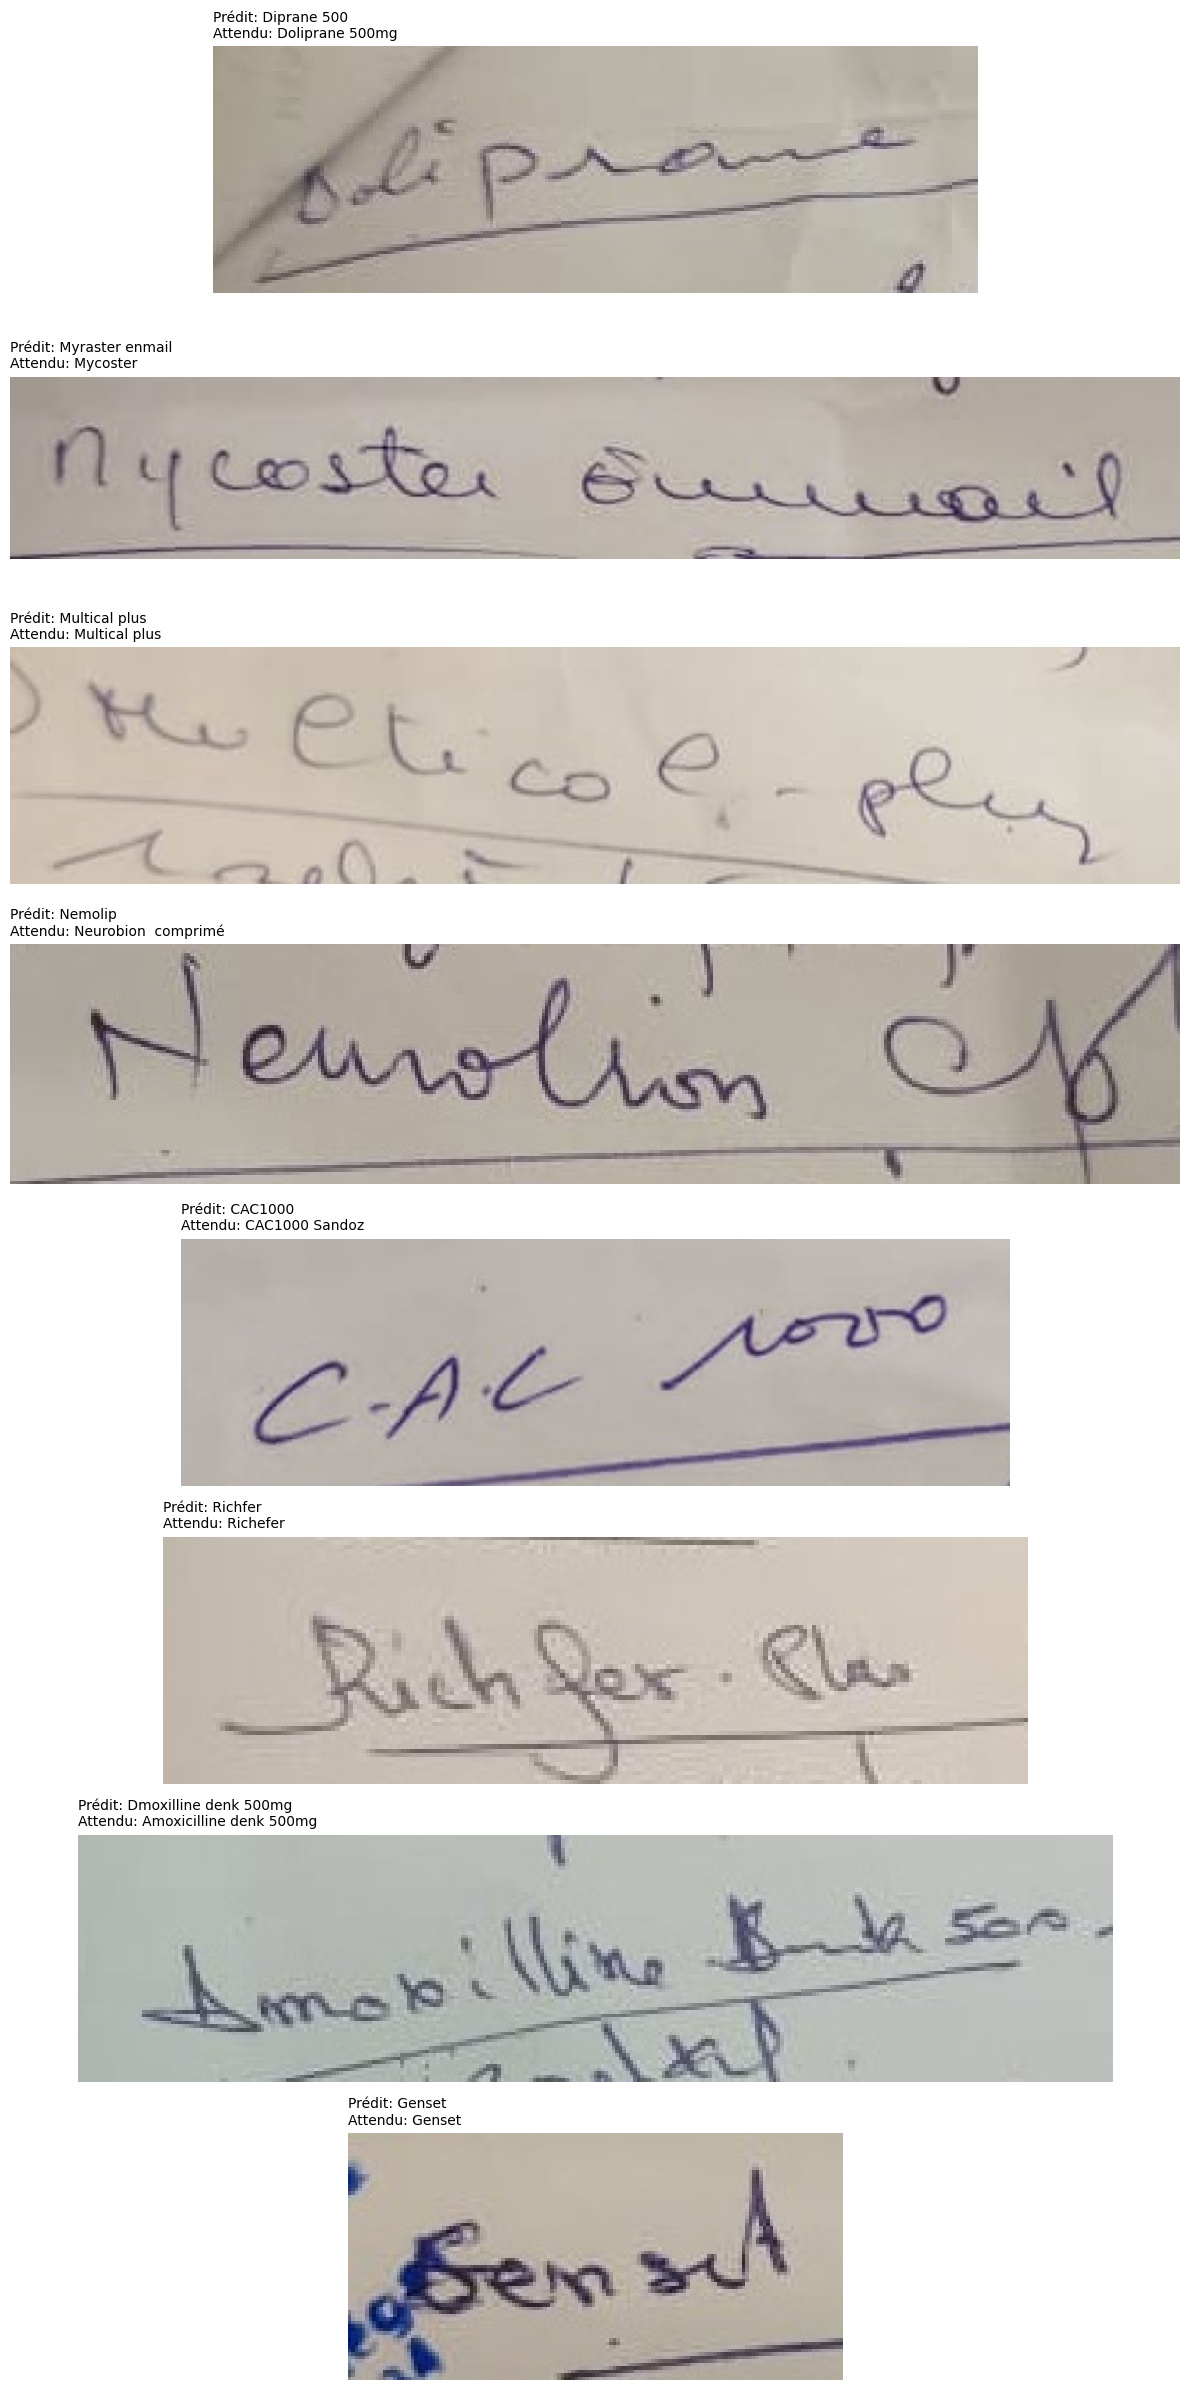

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# Charger le modèle finetuné
finetuned_model = VisionEncoderDecoderModel.from_pretrained(FINAL_DIR).to(device)
finetuned_processor = TrOCRProcessor.from_pretrained(FINAL_DIR)

# Tester sur quelques crops du jeu d'évaluation
test_df = pd.read_csv(EVAL_CSV).drop_duplicates(subset='file_name', keep='last').head(8)

print("=" * 70)
print("TEST DU MODÈLE FINE-TUNÉ")
print("=" * 70)

fig, axes = plt.subplots(len(test_df), 1, figsize=(12, 3 * len(test_df)))
if len(test_df) == 1:
    axes = [axes]

for i, (_, row) in enumerate(test_df.iterrows()):
    img_path = os.path.join(IMAGES_DIR, str(row['file_name']))
    image = Image.open(img_path).convert('RGB')

    pixel_values = finetuned_processor(image, return_tensors='pt').pixel_values.to(device)
    generated_ids = finetuned_model.generate(pixel_values)
    prediction = finetuned_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Texte attendu (une seule ligne par crop)
    expected = str(row['text']).strip()

    axes[i].imshow(image)
    axes[i].set_title(f"Prédit: {prediction}\nAttendu: {expected}", fontsize=10, loc='left')
    axes[i].axis('off')

    match = '✅' if prediction.lower().strip() == expected.lower().strip() else '❌'
    print(f"\n📸 {row['file_name']}  {match}")
    print(f"   Attendu : {expected}")
    print(f"   Prédit  : {prediction}")

plt.tight_layout()
plt.show()

## Étape 9 — Télécharger le modèle sur votre machine

Le modèle sera compressé en ZIP puis téléchargé automatiquement. Vous devrez ensuite le décompresser dans votre projet HCR4.

In [16]:
# Compression du modèle
!zip -r trocr_finetuned_hcr4.zip trocr_finetuned_hcr4/

# Téléchargement automatique
from google.colab import files
files.download('trocr_finetuned_hcr4.zip')

print("\n" + "=" * 60)
print("📦 Téléchargement lancé !")
print("")
print("Pour utiliser ce modèle dans HCR4 :")
print("  1. Décompressez le ZIP dans : backend/ai/finetuning/")
print("  2. Modifiez backend/config.py :")
print('     HTR_MODEL_NAME = "backend/ai/finetuning/trocr_finetuned_hcr4"')
print("  3. Relancez l'application : python run.py")
print("=" * 60)

  adding: trocr_finetuned_hcr4/ (stored 0%)
  adding: trocr_finetuned_hcr4/model.safetensors (deflated 7%)
  adding: trocr_finetuned_hcr4/generation_config.json (deflated 58%)
  adding: trocr_finetuned_hcr4/config.json (deflated 74%)
  adding: trocr_finetuned_hcr4/processor_config.json (deflated 53%)
  adding: trocr_finetuned_hcr4/tokenizer_config.json (deflated 51%)
  adding: trocr_finetuned_hcr4/tokenizer.json (deflated 82%)
  adding: trocr_finetuned_hcr4/training_args.bin (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Téléchargement lancé !

Pour utiliser ce modèle dans HCR4 :
  1. Décompressez le ZIP dans : backend/ai/finetuning/
  2. Modifiez backend/config.py :
     HTR_MODEL_NAME = "backend/ai/finetuning/trocr_finetuned_hcr4"
  3. Relancez l'application : python run.py


## Étape 10 — Visualisation de l'évolution du CER et de la Loss

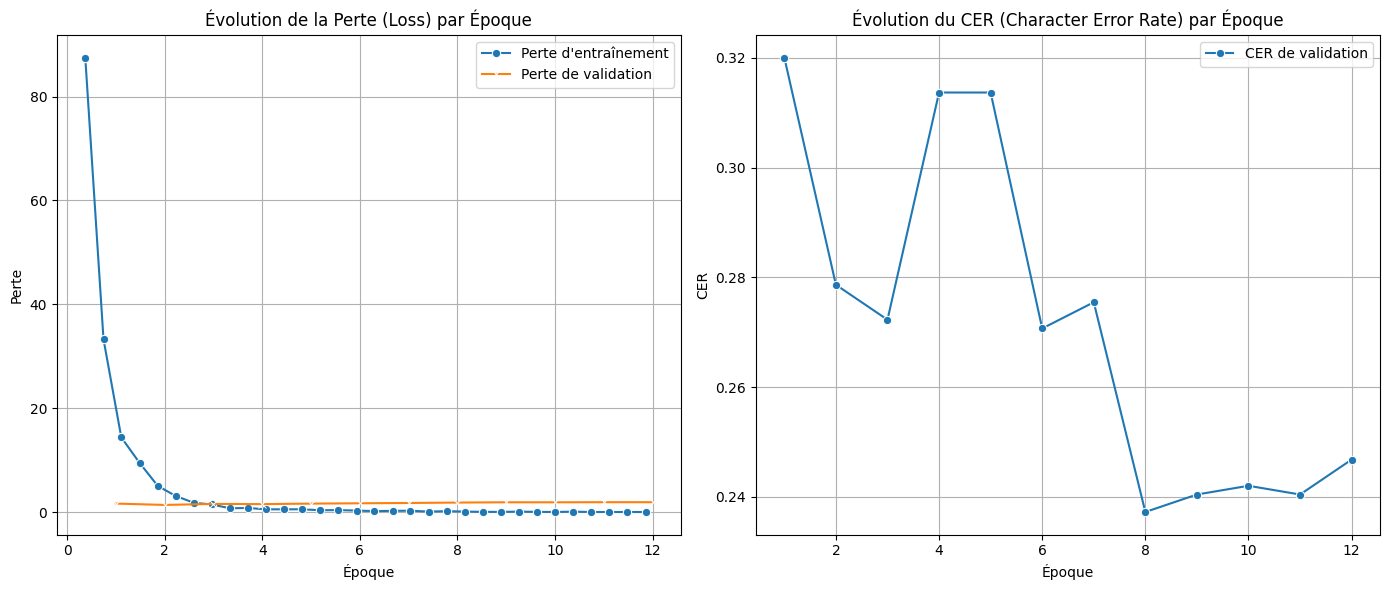

In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Trouver le répertoire du dernier checkpoint
checkpoint_dirs = [d for d in os.listdir('./checkpoints') if os.path.isdir(os.path.join('./checkpoints', d)) and d.startswith('checkpoint-')]

if not checkpoint_dirs:
    print("Aucun répertoire de checkpoint trouvé.")
else:
    # Trier les checkpoints par numéro pour obtenir le plus récent
    latest_checkpoint = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[1]))[-1]
    trainer_state_path = os.path.join('./checkpoints', latest_checkpoint, 'trainer_state.json')

    if os.path.exists(trainer_state_path):
        with open(trainer_state_path, 'r') as f:
            trainer_state = json.load(f)

        log_history = trainer_state['log_history']

        # Filtrer les logs d'évaluation (contenant eval_loss et eval_cer)
        eval_logs = [log for log in log_history if 'eval_loss' in log]
        # Filtrer les logs de perte d'entraînement (contenant loss, mais pas eval_loss)
        train_loss_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]

        # Convertir en DataFrame pour faciliter le traçage
        eval_df = pd.DataFrame(eval_logs)
        train_df = pd.DataFrame(train_loss_logs)

        if not eval_df.empty:
            plt.figure(figsize=(14, 6))

            # Graphique de la perte (Loss)
            plt.subplot(1, 2, 1)
            sns.lineplot(x='epoch', y='loss', data=train_df, label='Perte d\'entraînement', marker='o')
            sns.lineplot(x='epoch', y='eval_loss', data=eval_df, label='Perte de validation', marker='x')
            plt.title("Évolution de la Perte (Loss) par Époque")
            plt.xlabel("Époque")
            plt.ylabel("Perte")
            plt.legend()
            plt.grid(True)

            # Graphique du CER
            plt.subplot(1, 2, 2)
            sns.lineplot(x='epoch', y='eval_cer', data=eval_df, label='CER de validation', marker='o')
            plt.title("Évolution du CER (Character Error Rate) par Époque")
            plt.xlabel("Époque")
            plt.ylabel("CER")
            plt.legend()
            plt.grid(True)

            plt.tight_layout()
            plt.show()
        else:
            print("Aucune donnée d'évaluation trouvée dans trainer_state.json pour le traçage.")
    else:
        print(f"Le fichier {trainer_state_path} n'a pas été trouvé.")